In [229]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup

In [230]:
import os

os.chdir(r"C:\Kaggle_Competition\Playground\S6E6-STELLAR-CLASS")
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
import json
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, balanced_accuracy_score
from sklearn.inspection import permutation_importance
import mlflow
from tqdm.notebook import tqdm
import itertools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    TargetEncoder,
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
    KBinsDiscretizer
)
from feature_engine.outliers import Winsorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
from catboost import CatBoostClassifier
from pytabkit import (
    RealMLP_TD_Classifier,
    TabM_D_Classifier,
    Resnet_RTDL_D_Classifier,
    TabM_HPO_Classifier,
    RealMLP_HPO_Classifier,
    FTT_D_Classifier,
)
from sklearn.manifold import TSNE

import tabpfn_client
from tabpfn_client import TabPFNClassifier
from autogluon.tabular import TabularPredictor
pd.set_option("display.max_columns", None)

from dotenv import load_dotenv
import shap
from shap.explainers import LinearExplainer
import config
import warnings
warnings.filterwarnings("ignore")

In [231]:
load_dotenv(r'.env')

api_key = os.getenv('api_key')

In [232]:
train = pd.read_csv("data/raw/train.csv")
test = pd.read_csv("data/raw/test.csv")
orig = pd.read_csv("data/orig/star_classification.csv")

train_ids = train[config.ID_COL].values
test_ids = test[config.ID_COL].values

print(f"Shape of train data: {train.shape}")
print(f"Shape of test data: {test.shape}")
print(f"Shape of orig data: {orig.shape}")

Shape of train data: (577347, 12)
Shape of test data: (247435, 11)
Shape of orig data: (100000, 18)


In [233]:
# Quantitative features
num_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

# Qualitative features
cat_cols = ["spectral_type", "galaxy_population"]

# Target column
target = "class"

In [234]:
# Train data
X = train.drop(["id", config.TARGET_COL], axis=1)
y = train[config.TARGET_COL]

# Orig data
orig = orig.drop(index=79543).reset_index(drop=True)

def spectral_type(g, r):
    return pd.cut(
        r - g,
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=["M", "G/K", "A/F", "O/B"]
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u - r,
        [-np.inf, 2.2, np.inf],
        labels=["Blue_Cloud", "Red_Sequence"]
    ).astype(str)

orig["spectral_type"] = spectral_type(
    orig["g"],
    orig["r"]
)

orig["galaxy_population"] = galaxy_population(
    orig["u"],
    orig["r"]
)
X_orig = orig[num_cols + cat_cols]
y_orig = orig[target]

# Test data
X_test = test.drop("id", axis=1)

enc = LabelEncoder()
y = enc.fit_transform(y)
y_orig = enc.transform(y_orig)

In [235]:
print(X.shape)
print(X_orig.shape)
print(X_test.shape)

(577347, 10)
(99999, 10)
(247435, 10)


### Feature engineering

In [236]:
def fe(df):
    # Calculate consecutive color differences (adjacent bands)
    df["u_g"] = df["u"] - df["g"]
    df["g_r"] = df["g"] - df["r"]
    df["r_i"] = df["r"] - df["i"]
    df["i_z"] = df["i"] - df["z"]

    # Calculate crucial extended color differences
    df["u_r"] = df["u"] - df["r"]
    df["u_i"] = df["u"] - df["i"]

    df["redshift_g_r"] = df["redshift"] * df["g_r"]
    df["redshift_u_g"] = df["redshift"] * df["u_g"]

    alpha_rad = np.radians(df["alpha"])
    delta_rad = np.radians(df["delta"])

    df["coord_X"] = np.cos(delta_rad) * np.cos(alpha_rad)
    df["coord_Y"] = np.cos(delta_rad) * np.sin(alpha_rad)
    df["coord_Z"] = np.sin(delta_rad)

    df["coord_radial_dist"] = np.sqrt(df["alpha"] ** 2 + df["delta"] ** 2)

    # deviation from mean redshift
    df["redshift_dev_from_galaxy_population"] = df["redshift"] - df.groupby("galaxy_population")["redshift"].transform("mean")
    df["redshift_dev_from_spectral_type"] = df["redshift"] - df.groupby("spectral_type")["redshift"].transform("mean")

    # Calculate curvature
    df["mag_curvature"] = (df["u"] - 2 * df["r"] + df["z"]).astype("float32")
    df["blue_curvature"] = (df["u"] - 2 * df["g"] + df["r"]).astype("float32")
    df["red_curvature"] = (df["r"] - 2 * df["i"] + df["z"]).astype("float32")

    # Drop irrelevant cols
    df = df.drop(['galaxy_population', 'spectral_type'], axis=1)

    return df

X = fe(X)
X_test = fe(X_test)

In [237]:
print(X.shape)
print(X_test.shape)

(577347, 25)
(247435, 25)


### Logistic Regression

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "lr"
VERSION = "v1"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        # Preprocessor
        preprocess = ColumnTransformer(
            transformers=[
                ("encoder", OneHotEncoder(handle_unknown="ignore"), cat_cols),
                ("scaler", StandardScaler(), num_cols),
            ],
            remainder="passthrough",
        )

        # Fit and transform preprocessor 
        X_train_processed = preprocess.fit_transform(X_train, y_train)
        X_valid_processed = preprocess.transform(X_valid)
        X_test_processed = preprocess.transform(X_test)

        model = LogisticRegression(**config.LR_PARAMS)

        # Training model
        model.fit(X_train_processed, y_train)

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid_processed)
        fold_test_predictions = model.predict_proba(X_test_processed)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid_processed)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.LR_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Mlflow preprocessing steps logging
    mlflow.log_text(str(preprocess), "steps.txt")

    # Garbase collector
    if config.N_FOLDS < 5:
        del X_train, y_train, X_valid, y_valid, model, X_train_processed, X_valid_processed, X_test_processed

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=enc.classes_)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=enc.classes_)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

In [ ]:
feature_names = preprocess.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_valid_processed_df = pd.DataFrame(
    X_valid_processed,
    columns=feature_names,
    index=X_valid.index
)

explainer = shap.LinearExplainer(
    model,
    X_train_processed_df # background data
)

shapley_values = explainer(
    X_valid_processed_df
)

In [ ]:
for i in range(3):
    shap.plots.bar(
        shapley_values[..., i]
    )

### HistGBM

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "histgbm"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        # Preprocessor
        # preprocess = ColumnTransformer(
        #    transformers=[
        #        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        #    ], remainder='passthrough'
        # )

        model = Pipeline(
            steps=[
                # ("preprocess", preprocess),
                ("classifier", HistGradientBoostingClassifier(**config.HISTGBM_PARAMS))
            ]
        )

        # Training model
        model.fit(X_train, y_train)

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        fold_test_predictions = model.predict_proba(X_test)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.HISTGBM_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Mlflow preprocessing steps logging
    mlflow.log_text(str(model.steps), "steps.txt")

    # Garbase collector
    if config.N_FOLDS < 5:
        del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=model.classes_)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=model.classes_)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

### LightGBM

In [66]:
X[cat_cols] = X[cat_cols].astype('category')
X_test[cat_cols] = X_test[cat_cols].astype('category')

In [67]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "lightgbm"
VERSION = "v1"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        model = LGBMClassifier(**config.LGBM_PARAMS)

        # Training model
        model.fit(
            X_train, 
            y_train, 
            eval_set=[(X_valid, y_valid)], 
            callbacks=[early_stopping(100), log_evaluation(period=1000)]
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        fold_test_predictions = model.predict_proba(X_test)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.LGBM_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Garbase collector
    if config.N_FOLDS < 5:
        del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=enc.classes_)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=enc.classes_)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

Model Training:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
[1000]	valid_0's multi_logloss: 0.10982
[2000]	valid_0's multi_logloss: 0.103725
[3000]	valid_0's multi_logloss: 0.100734
[4000]	valid_0's multi_logloss: 0.0990949
[5000]	valid_0's multi_logloss: 0.0982605
Did not meet early stopping. Best iteration is:
[4999]	valid_0's multi_logloss: 0.0982591
Fold: 1 | LogLoss: 0.09826 | BACC: 0.96453
Training until validation scores don't improve for 100 rounds
[1000]	valid_0's multi_logloss: 0.111879
[2000]	valid_0's multi_logloss: 0.10573
[3000]	valid_0's multi_logloss: 0.102845
[4000]	valid_0's multi_logloss: 0.101382
[5000]	valid_0's multi_logloss: 0.100649
Did not meet early stopping. Best iteration is:
[5000]	valid_0's multi_logloss: 0.100649
Fold: 2 | LogLoss: 0.10065 | BACC: 0.96523
Training until validation scores don't improve for 100 rounds
[1000]	valid_0's multi_logloss: 0.113716
[2000]	valid_0's multi_logloss: 0.107766
[3000]	valid_0's multi_logloss: 0.10491
[4000]	valid_0's 

### XGBoost

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "xgbm"
VERSION = "v9"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        model = XGBClassifier(**config.XGB_PARAMS)

        # Training model
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=1000
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        fold_test_predictions = model.predict_proba(X_test)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.LGBM_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Garbase collector
    if config.N_FOLDS < 5:
        del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=enc.classes_)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=enc.classes_)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

Model Training:   0%|          | 0/5 [00:00<?, ?it/s]

[0]	validation_0-mlogloss:0.93749
[1000]	validation_0-mlogloss:0.08928


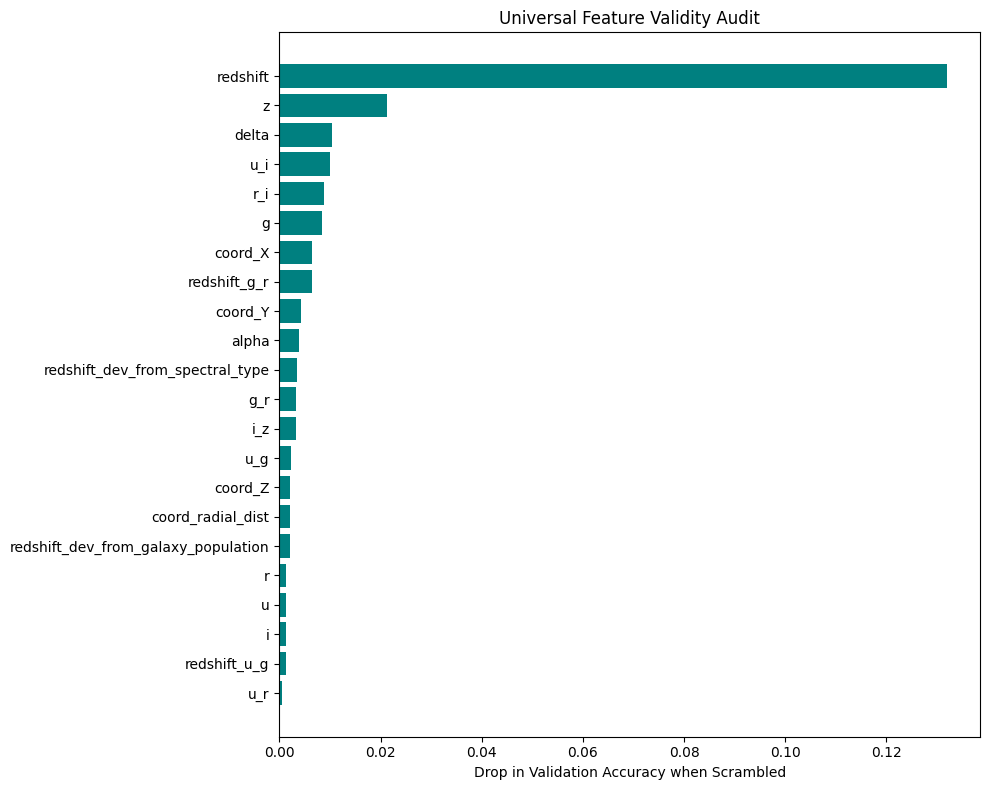

In [209]:
result = permutation_importance(
    model, X_valid, y_valid, n_repeats=5, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance_Drop": result.importances_mean}
).sort_values(by="Importance_Drop", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df["Feature"], importance_df["Importance_Drop"], color="teal"
)
plt.xlabel("Drop in Validation Accuracy when Scrambled")
plt.title("Universal Feature Validity Audit")
plt.tight_layout()
plt.show()

### ResNet

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "resnet"
VERSION = "v1"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        # Preprocessor
        # preprocess = ColumnTransformer(
        #    transformers=[
        #        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        #    ], remainder='passthrough'
        # )

        model = Pipeline(
            steps=[
                # ("preprocess", preprocess),
                ("classifier", Resnet_RTDL_D_Classifier(**config.RESNET_PARAMS))
            ]
        )

        # Training model
        model.fit(
            X_train, 
            y_train, 
            classifier__X_val=X_valid,
            classifier__y_val=y_valid 
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        fold_test_predictions = model.predict_proba(X_test)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.RESNET_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Mlflow preprocessing steps logging
    mlflow.log_text(str(model.steps), "steps.txt")

    # Garbase collector
    if config.N_FOLDS < 5:
        del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=model.classes_)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=model.classes_)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

### CatBoost

In [ ]:
category_map = {}
color_pairs = [
    ('u', 'g'),
    ('u', 'r'),
]
important_combos = [
    ('alpha_cat_', 'delta_cat_'),
    ('u_cat_', 'z_cat_'),
]
important_combos = sorted(important_combos)
def feature_engineering(df, fit=False):
    # Arithmetic interaction
    df['_g_/_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).astype('float32')
    df['_i_/_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).astype('float32')
    for a, b in color_pairs:
        df[f"_{a}-{b}"] = (df[a] - df[b]).astype('float32')

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Categorize numericals
    for col in num_cols:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Discretize numericals
    bin_config = {'delta': [100, 500]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_test = X_test.reindex(sorted(X_test.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "catgbm"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        model = CatBoostClassifier(**config.CATBOOST_PARAMS)

        # Training model
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose_eval=1000,
            cat_features=cat_cols
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        fold_test_predictions = model.predict_proba(X_test)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.CATBOOST_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Garbase collector
    if config.N_FOLDS < 5:
        del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=model.classes_)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=model.classes_)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

### TABM

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "tabm"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        model = TabM_D_Classifier(**config.TABM_PARAMS)

        # Training model
        model.fit(
            X_train,
            y_train,
            X_valid,
            y_valid,
            cat_col_names=cat_cols
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        fold_test_predictions = model.predict_proba(X_test)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow params logging
    mlflow.log_params(config.TABM_PARAMS)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Garbase collector
    del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=config.PROB_COLS)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=config.PROB_COLS)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

### Tabpfn

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)

# --- SPLIT X_TEST INTO TWO BATCHES ---
half_idx = len(X_test) // 2
X_test_batch1 = X_test.iloc[:half_idx]
X_test_batch2 = X_test.iloc[half_idx:]

# Separate prediction arrays for each batch
test_predictions_b1 = np.zeros((len(X_test_batch1), config.N_CLASSES), dtype=np.float32)
test_predictions_b2 = np.zeros((len(X_test_batch2), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "tabpfn"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data
        X_train = X.iloc[train_indices]
        X_valid = X.iloc[valid_indices]

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        # Initiate model
        model = TabPFNClassifier(
            random_state=config.SEED,
            balance_probabilities=True
        )

        # Training model
        model.fit(
            X_train,
            y_train
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid)
        
        # Predict in two batches
        fold_test_predictions_b1 = model.predict_proba(X_test_batch1)
        fold_test_predictions_b2 = model.predict_proba(X_test_batch2)

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        
        test_predictions_b1 += fold_test_predictions_b1 * test_weight
        test_predictions_b2 += fold_test_predictions_b2 * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    oof_preds = model.classes_[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Garbase collector
    del X_train, y_train, X_valid, y_valid, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=config.PROB_COLS)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

test_predictions = np.vstack([test_predictions_b1, test_predictions_b2])

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=config.PROB_COLS)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)

### AutoGluon

In [ ]:
# Predictions
oof_predictions = np.zeros((len(train), config.N_CLASSES), dtype=np.float32)
test_predictions = np.zeros((len(X_test), config.N_CLASSES), dtype=np.float32)

# Experiment Setup
EXPERIMENT_NAME = "autogluon"
VERSION = "v2"
RUN_NAME = f"{EXPERIMENT_NAME}_{VERSION}_seed{config.SEED}"

mlflow.set_experiment(EXPERIMENT_NAME)

# CV
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.SEED)

fold_loglosses = []
fold_baccs = []

test_weight = 1 / config.N_FOLDS

with mlflow.start_run(run_name=RUN_NAME):
    for fold, (train_indices, valid_indices) in tqdm(
        enumerate(skf.split(X, y), start=1), desc="Model Training", total=config.N_FOLDS
    ):
        # Train and validation data split
        X_train = X.iloc[train_indices].copy()
        X_valid = X.iloc[valid_indices].copy()

        y_train = y[train_indices]
        y_valid = y[valid_indices]

        # Combine features and target into a single DataFrame for AutoGluon
        train_data = X_train.copy()
        train_data['class'] = y_train

        valid_data = X_valid.copy()
        valid_data['class'] = y_valid

        fold_path = f"AutogluonModels/{EXPERIMENT_NAME}_{VERSION}_fold_{fold}"

        # 2. Initialize and train the TabularPredictor
        model = TabularPredictor(
            label='class', 
            problem_type='multiclass',
            eval_metric='balanced_accuracy',
            path=fold_path
        ).fit(
            train_data=train_data,
            tuning_data=valid_data,
            time_limit=300,
            presets='best_quality',
            refit_full=False
        )

        # Fold level predictions
        fold_oof_predictions = model.predict_proba(X_valid).values
        fold_test_predictions = model.predict_proba(X_test).values

        # Updating global predictions
        oof_predictions[valid_indices] = fold_oof_predictions
        test_predictions += fold_test_predictions * test_weight

        # Inference and scoring
        fold_logloss = log_loss(y_valid, fold_oof_predictions)
        fold_preds = model.predict(X_valid)

        fold_bacc = balanced_accuracy_score(y_valid, fold_preds)

        fold_loglosses.append(fold_logloss)
        fold_baccs.append(fold_bacc)

        print(f"Fold: {fold} | LogLoss: {fold_logloss:.5f} | BACC: {fold_bacc:.5f}")

    # Calculating important metrices
    oof_logloss = log_loss(y, oof_predictions)
    
    # Updated class extraction to handle AutoGluon's class alignment safely
    oof_preds = np.array(model.classes_)[np.argmax(oof_predictions, axis=1)]
    oof_bacc = balanced_accuracy_score(y, oof_preds)
    std_oof_logloss = np.std(fold_loglosses)
    std_oof_bacc = np.std(fold_baccs)

    # Mlflow metrics logging
    mlflow.log_metric("oof_logloss", oof_logloss)
    mlflow.log_metric("oof_bacc", oof_bacc)
    mlflow.log_metric("std_oof_logloss", std_oof_logloss)
    mlflow.log_metric("std_oof_bacc", std_oof_bacc)

    # Mlflow input feature names logging
    mlflow.log_dict({"feature_names": list(X_train.columns)}, "feature_names.json")

    # Garbage collector
    del X_train, y_train, X_valid, y_valid, train_data, valid_data, model

# Saving oof predictions
oof_proba_df = pd.DataFrame(oof_predictions, columns=config.PROB_COLS)
oof_proba_df.insert(0, "id", train_ids)

oof_path = Path(config.OOF_PROBA_DIR, f"{RUN_NAME}_oof_proba.csv")
oof_proba_df.to_csv(oof_path, index=False)

# Saving test predictions
test_proba_df = pd.DataFrame(test_predictions, columns=config.PROB_COLS)
test_proba_df.insert(0, "id", test_ids)

test_path = Path(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv")
test_proba_df.to_csv(test_path, index=False)